In [1]:
import genetick_AI
import pandas
import numpy as np
import pandas as pd

def f_2(x):
    return ((1 - x) ** 76)/((1 - x) ** 76 + 10 * x ** 12)

def f_3(x):
    return (1-x)*(1-f_2(x)-f_5(x))

def f_4(x):
    return f_3(1 - x)

def f_5(x):
    return f_2(1 - x)

In [2]:
n,m = 10,10
matrix, perf, diff = genetick_AI.generate_rating_matrix(n,m)
df = pandas.DataFrame(matrix)
df

,0,1,2,3,4,5,6,7,8,9
0,4.0,4.0,3.0,4.0,4.0,4.0,3.0,4.0,4.0,3.0
1,4.0,4.0,4.0,3.0,4.0,3.0,4.0,3.0,4.0,4.0
2,3.0,4.0,3.0,4.0,4.0,4.0,3.0,3.0,3.0,4.0
3,3.0,4.0,3.0,3.0,4.0,4.0,4.0,3.0,4.0,3.0
4,3.0,5.0,3.0,3.0,4.0,3.0,4.0,4.0,4.0,3.0
5,3.0,3.0,3.0,3.0,3.0,4.0,4.0,3.0,3.0,3.0
6,4.0,3.0,4.0,4.0,3.0,4.0,4.0,3.0,4.0,4.0
7,4.0,4.0,4.0,3.0,3.0,4.0,4.0,3.0,3.0,3.0
8,3.0,3.0,3.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0
9,3.0,3.0,4.0,4.0,4.0,3.0,4.0,4.0,4.0,3.0


In [3]:
def calculate_f_matrix(ratings_matrix, st_it, student_alpha=2, student_beta=2,
                       item_alpha=2, item_beta=2):
    """
    Returns a matrix of f_rating contributions (without Beta priors) for observed ratings.

    Parameters
    ----------
    ratings_matrix : np.ndarray, shape (n_students, n_items)
        Observed ratings (2..5). Unobserved entries should be 0, NaN, or a sentinel.
    st_it : np.ndarray
        Concatenated vector: first n_students entries = student parameters,
        remaining = item parameters. All values in (0,1).
    student_alpha, student_beta, item_alpha, item_beta : float
        Ignored (kept only for API compatibility). Excluded from calculation.

    Returns
    -------
    f_matrix : np.ndarray, same shape as ratings_matrix
        For each observed rating, f_rating( student_i / (student_i + item_j) ).
        Unobserved cells are set to 0.0.
    """
    # Dictionary mapping rating values to their corresponding functions
    methods = {2: f_2, 3: f_3, 4: f_4, 5: f_5}   # f_2..f_5 must be defined elsewhere

    n_students, n_items = ratings_matrix.shape
    students = st_it[:n_students]
    items = st_it[n_students:]

    # Initialize matrix with zeros (unrated cells stay 0)
    f_matrix = np.zeros_like(ratings_matrix, dtype=float)

    # Fill f_rating contributions for each observed rating value
    for rating, func in methods.items():
        mask = (ratings_matrix == rating)
        if not np.any(mask):
            continue
        rows, cols = np.where(mask)
        v1_vals = students[rows]
        v2_vals = items[cols]
        ratio = v1_vals / (v1_vals + v2_vals)
        f_vals = func(ratio)
        f_matrix[rows, cols] = f_vals

    return f_matrix
a = np.concatenate((perf,diff))
prob_m = calculate_f_matrix(matrix,a)
df = pandas.DataFrame(prob_m)
df

,0,1,2,3,4,5,6,7,8,9
0,0.420816,0.756734,0.492385,0.533699,0.712005,0.492119,0.301524,0.544310,0.617383,0.415763
1,0.371106,0.717927,0.455719,0.518255,0.667544,0.559611,0.652943,0.507586,0.567192,0.532986
2,0.578009,0.757422,0.491181,0.534897,0.712991,0.493322,0.300510,0.454496,0.381480,0.585406
3,0.729530,0.615232,0.655307,0.631326,0.557800,0.330829,0.541689,0.621332,0.451539,0.582421
4,0.484228,0.967430,0.398194,0.373430,0.721186,0.413139,0.760528,0.636507,0.702867,0.326794
5,0.750632,0.448378,0.711888,0.689984,0.507473,0.275561,0.476270,0.680775,0.612204,0.644478
6,0.472257,0.143716,0.559418,0.585001,0.247021,0.544088,0.740370,0.404670,0.665253,0.633794
7,0.303024,0.652208,0.381532,0.593515,0.403324,0.367015,0.580917,0.583172,0.508764,0.543223
8,0.661934,0.312218,0.579821,0.445838,0.634750,0.594844,0.380470,0.543588,0.468553,0.503077
9,0.540481,0.191751,0.546765,0.572521,0.742986,0.468637,0.730486,0.582939,0.653758,0.378167


In [4]:
rm = pandas.DataFrame(matrix)
out = []
for column in rm.columns:
    print(rm[column].value_counts())

0
3.0    6
4.0    4
Name: count, dtype: int64
1
4.0    5
3.0    4
5.0    1
Name: count, dtype: int64
2
3.0    6
4.0    4
Name: count, dtype: int64
3
4.0    5
3.0    5
Name: count, dtype: int64
4
4.0    7
3.0    3
Name: count, dtype: int64
5
4.0    6
3.0    4
Name: count, dtype: int64
6
4.0    7
3.0    3
Name: count, dtype: int64
7
3.0    7
4.0    3
Name: count, dtype: int64
8
4.0    6
3.0    4
Name: count, dtype: int64
9
3.0    7
4.0    3
Name: count, dtype: int64


In [5]:
del a
res = genetick_AI.try_find_opt(matrix)

In [6]:
# print(pandas.Series(res[:n]),'\n',pandas.Series(res[n:]))
# print(pandas.Series(perf),'\n', pandas.Series(diff))
df1 = pandas.DataFrame((pandas.Series(res[:n]),pandas.Series(perf)))
df2 = pandas.DataFrame((pandas.Series(res[n:]),pandas.Series(diff)))
df1

,0,1,2,3,4,5,6,7,8,9
0,0.600752,0.691141,0.535831,0.515878,0.812594,0.213559,0.689900,0.513133,0.309719,0.614268
1,0.615635,0.499997,0.618608,0.314110,0.902516,0.241679,0.758234,0.368389,0.432748,0.720396


In [7]:
df2

,0,1,2,3,4,5,6,7,8,9
0,0.650892,0.205768,0.648431,0.557572,0.328081,0.414497,0.347151,0.691190,0.469394,0.731630
1,0.847320,0.196445,0.597164,0.537891,0.249013,0.635355,0.265762,0.515403,0.381534,0.438108


In [8]:
print(np.abs(perf-res[:n]),'\n',np.abs(diff-res[n:]))
print(max(np.abs(perf-res[:n])),max(np.abs(diff-res[n:])))

[0.0148839  0.19114436 0.0827768  0.20176791 0.08992216 0.02812042
 0.06833398 0.14474344 0.12302839 0.10612719] 
 [0.19642773 0.00932272 0.05126715 0.01968146 0.07906826 0.22085711
 0.08138884 0.17578661 0.08785997 0.29352235]
0.20176790890603258 0.29352234766459573


In [9]:
prob_m_ap = calculate_f_matrix(matrix,np.array(res))
df1 = pandas.DataFrame(prob_m_ap)
df1

,0,1,2,3,4,5,6,7,8,9
0,0.479970,0.744683,0.519084,0.518639,0.646781,0.591728,0.366231,0.464999,0.561374,0.549115
1,0.514996,0.761620,0.515942,0.446517,0.678106,0.374894,0.665652,0.500018,0.595537,0.485771
2,0.548479,0.722528,0.547540,0.490058,0.620238,0.563838,0.393158,0.563307,0.466954,0.422759
3,0.557858,0.714861,0.556923,0.519420,0.611259,0.554484,0.597753,0.572619,0.523590,0.586473
4,0.444755,0.433686,0.443819,0.406938,0.712378,0.337789,0.700666,0.540366,0.633855,0.473785
5,0.752327,0.490710,0.751685,0.723050,0.605718,0.340032,0.380872,0.760657,0.687300,0.758957
6,0.514547,0.227189,0.515493,0.553039,0.322286,0.624685,0.665252,0.500467,0.595104,0.485322
7,0.440826,0.713772,0.441760,0.520752,0.390009,0.553165,0.596469,0.573924,0.477741,0.587767
8,0.677581,0.399172,0.676753,0.357111,0.485605,0.572339,0.528492,0.690562,0.602472,0.702578
9,0.514474,0.250808,0.486472,0.524191,0.651848,0.402907,0.638918,0.470539,0.566845,0.543600


In [10]:
df

,0,1,2,3,4,5,6,7,8,9
0,0.420816,0.756734,0.492385,0.533699,0.712005,0.492119,0.301524,0.544310,0.617383,0.415763
1,0.371106,0.717927,0.455719,0.518255,0.667544,0.559611,0.652943,0.507586,0.567192,0.532986
2,0.578009,0.757422,0.491181,0.534897,0.712991,0.493322,0.300510,0.454496,0.381480,0.585406
3,0.729530,0.615232,0.655307,0.631326,0.557800,0.330829,0.541689,0.621332,0.451539,0.582421
4,0.484228,0.967430,0.398194,0.373430,0.721186,0.413139,0.760528,0.636507,0.702867,0.326794
5,0.750632,0.448378,0.711888,0.689984,0.507473,0.275561,0.476270,0.680775,0.612204,0.644478
6,0.472257,0.143716,0.559418,0.585001,0.247021,0.544088,0.740370,0.404670,0.665253,0.633794
7,0.303024,0.652208,0.381532,0.593515,0.403324,0.367015,0.580917,0.583172,0.508764,0.543223
8,0.661934,0.312218,0.579821,0.445838,0.634750,0.594844,0.380470,0.543588,0.468553,0.503077
9,0.540481,0.191751,0.546765,0.572521,0.742986,0.468637,0.730486,0.582939,0.653758,0.378167


In [11]:
print(df.prod().prod(),df1.prod().prod(),(df1/df).prod().prod(),df1.prod().prod()/df.prod().prod())

2.032744503823956e-29 3.700652128431329e-28 18.205200513245725 18.205200513245714


In [12]:
import Parser_lib

In [13]:
sm1,sm2 = Parser_lib.parse('Grades.xls',sheet_name='24-25 1к 2п')

In [14]:
res1 = genetick_AI.try_find_opt(sm1)
res2 = genetick_AI.try_find_opt(sm2)

In [15]:
n_students, n_items = sm1.shape
res1, res2 = np.array(res1), np.array(res2)

In [16]:
print(np.abs(res1[:n_students]-res2[:n_students]))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [17]:
print(res1[n_students:], res2[n_students:])

[0.07896205 0.07448562 0.68571429 0.78107904 0.72340468 0.59490825
 0.74976976] [0.14267733 0.25123984 0.06228868 0.65104753 0.70362036]


In [18]:
df1 = pandas.DataFrame(sm1)
df1

,0,1,2,3,4,5,6
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.0,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,5.0,NaN,3.0,3.0,3.0,3.0
3,4.0,5.0,NaN,NaN,NaN,NaN,NaN
4,4.0,3.0,NaN,3.0,3.0,3.0,3.0
...,...,...,...,...,...,...,...
127,4.0,4.0,NaN,4.0,4.0,4.0,5.0
128,3.0,5.0,NaN,3.0,3.0,NaN,3.0
129,4.0,5.0,NaN,4.0,4.0,NaN,3.0
130,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df2 = pandas.DataFrame(sm2)
df2

,0,1,2,3,4
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,3.0,5.0,4.0,NaN,2.0
3,NaN,NaN,NaN,NaN,NaN
4,3.0,5.0,3.0,3.0,3.0
...,...,...,...,...,...
127,3.0,3.0,4.0,5.0,3.0
128,4.0,NaN,4.0,3.0,3.0
129,4.0,NaN,5.0,3.0,NaN
130,NaN,NaN,NaN,NaN,NaN


In [20]:
import matplotlib.pyplot as plt

(array([ 3.,  3.,  7.,  6.,  8.,  3.,  7., 13.,  7.,  6.,  7.,  6., 14.,
         5., 12.,  6.,  5.,  2.,  4.,  8.]),
 array([0.08224546, 0.12411605, 0.16598664, 0.20785723, 0.24972782,
        0.29159841, 0.33346899, 0.37533958, 0.41721017, 0.45908076,
        0.50095135, 0.54282194, 0.58469253, 0.62656312, 0.66843371,
        0.7103043 , 0.75217488, 0.79404547, 0.83591606, 0.87778665,
        0.91965724]),
 <BarContainer object of 20 artists>)

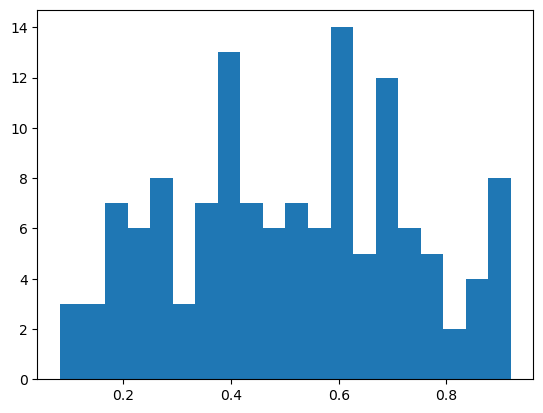

In [21]:
plt.hist(res1[:n_students],bins=20)

(array([ 3.,  3.,  7.,  6.,  8.,  3.,  7., 13.,  7.,  6.,  7.,  6., 14.,
         5., 12.,  6.,  5.,  2.,  4.,  8.]),
 array([0.08224546, 0.12411605, 0.16598664, 0.20785723, 0.24972782,
        0.29159841, 0.33346899, 0.37533958, 0.41721017, 0.45908076,
        0.50095135, 0.54282194, 0.58469253, 0.62656312, 0.66843371,
        0.7103043 , 0.75217488, 0.79404547, 0.83591606, 0.87778665,
        0.91965724]),
 <BarContainer object of 20 artists>)

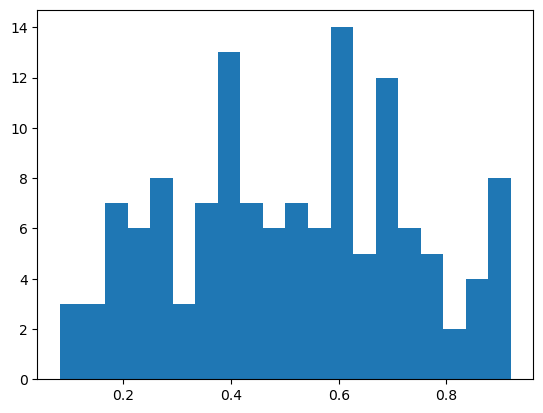

In [22]:
plt.hist(res2[:n_students],bins=20)

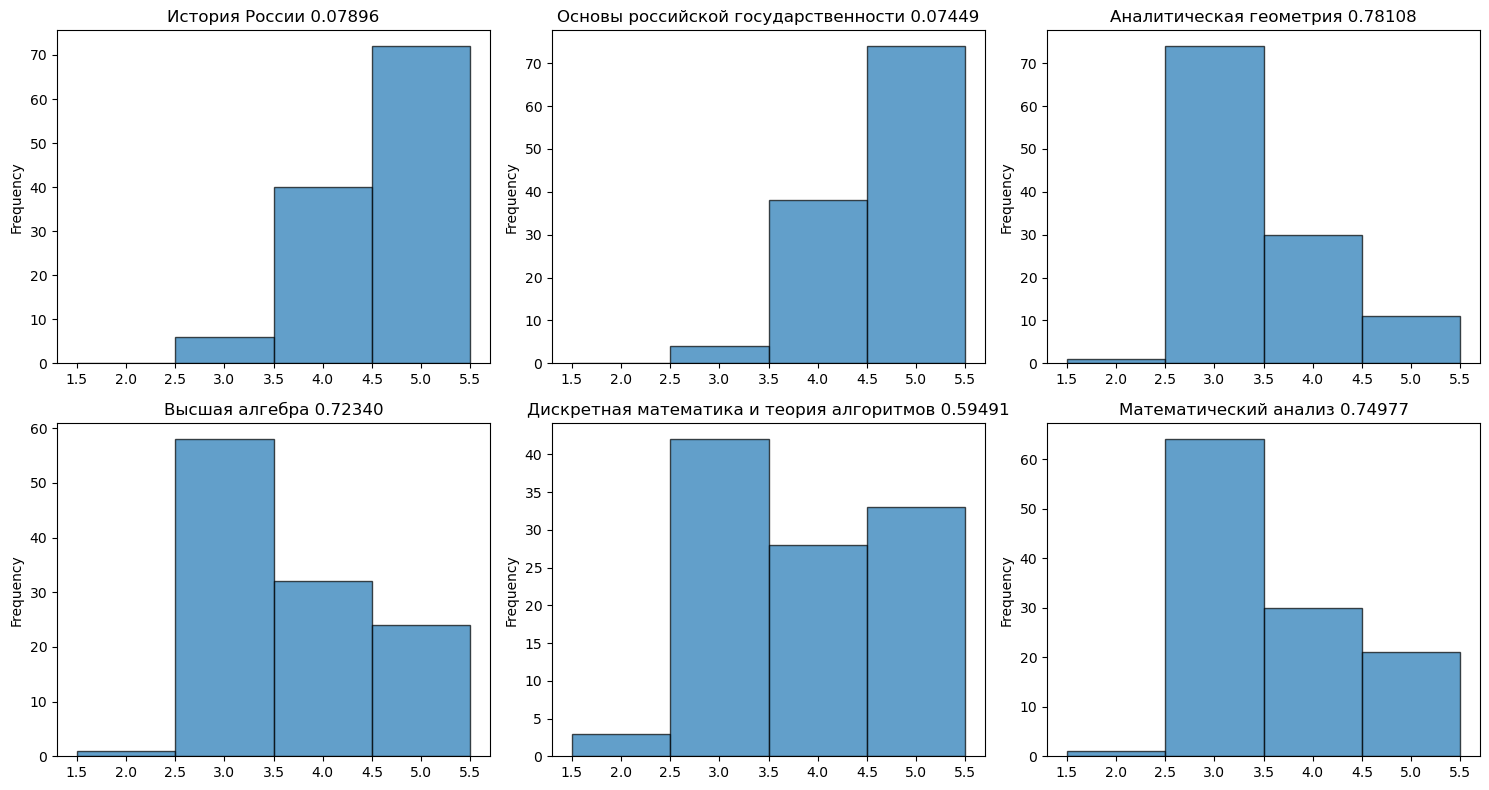

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# Sample DataFrame (replace with your own)
df = df1.drop(df1.columns[2],axis=1)

bins = [1.5, 2.5, 3.5, 4.5, 5.5]

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns
n_cols = len(numeric_cols)

# Define grid layout (e.g., up to 3 columns per row)
cols_per_row = 3
rows = math.ceil(n_cols / cols_per_row)

# Create subplots
fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, rows * 4))
axes = axes.flatten()  # Flatten in case of multiple rows

# Hide unused subplots if any
for i in range(n_cols, len(axes)):
    axes[i].set_visible(False)

# Plot histogram for each numeric column
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=bins, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_ylabel('Frequency')

axes[0].set_title(f'История России {res1[n_students:][0]:.5f}')
axes[1].set_title(f'Основы российской государственности {res1[n_students:][1]:.5f}')
axes[2].set_title(f'Аналитическая геометрия {res1[n_students:][3]:.5f}')
axes[3].set_title(f'Высшая алгебра {res1[n_students:][4]:.5f}')
axes[4].set_title(f'Дискретная математика и теория алгоритмов {res1[n_students:][5]:.5f}')
axes[5].set_title(f'Математический анализ {res1[n_students:][6]:.5f}')

plt.tight_layout()

# Save the figure as a picture (change filename/format as needed)
plt.savefig('histograms.png', dpi=300, bbox_inches='tight')
plt.show()